<a href="https://colab.research.google.com/github/Shaik-Imran08/Eye-Disease-Prediction/blob/main/eye_disease.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q kagglehub torch torchvision timm opencv-python matplotlib gradio

import os, time, copy, random, numpy as np, cv2
import matplotlib.pyplot as plt
import kagglehub
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split, Dataset, WeightedRandomSampler
from torchvision import datasets, transforms
import timm
from PIL import Image
import gradio as gr

from google.colab import drive
drive.mount('/content/drive')

# ---------------- GPU SETTINGS (T4 OPTIMIZED) ----------------
torch.backends.cudnn.benchmark = True
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)
print("GPU name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

# ---------------- CONFIG ----------------
img_size = 224
BATCH_SIZE = 16
NUM_EPOCHS = 25
LR = 3e-4
WEIGHT_DECAY = 1e-4
MODEL_NAME = "swin_tiny_patch4_window7_224"

SAVE_DIR = "/content/drive/MyDrive/Final/output"
os.makedirs(SAVE_DIR, exist_ok=True)
SAVE_PATH = os.path.join(SAVE_DIR, "best_swin_96plus.pth")

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

# ---------------- DATASET ----------------
print("Downloading dataset via kagglehub...")
path = kagglehub.dataset_download("gunavenkatdoddi/eye-diseases-classification")

DATA_DIR = os.path.join(path, "dataset")
if not os.path.isdir(DATA_DIR):
    DATA_DIR = path

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(img_size, scale=(0.85, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.AutoAugment(policy=transforms.AutoAugmentPolicy.IMAGENET),
    transforms.ColorJitter(0.3, 0.3, 0.3),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

val_test_transform = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

base_dataset = datasets.ImageFolder(DATA_DIR)
class_names = base_dataset.classes
NUM_CLASSES = len(class_names)

total_len = len(base_dataset)
train_len = int(0.7 * total_len)
val_len   = int(0.15 * total_len)
test_len  = total_len - train_len - val_len

train_base, val_base, test_base = random_split(
    base_dataset,
    [train_len, val_len, test_len],
    generator=torch.Generator().manual_seed(42)
)

class DatasetWithTransform(Dataset):
    def __init__(self, subset, transform):
        self.subset = subset
        self.transform = transform
    def __len__(self):
        return len(self.subset)
    def __getitem__(self, idx):
        img, label = self.subset[idx]
        img = self.transform(img)
        return img, label

train_dataset = DatasetWithTransform(train_base, train_transform)
val_dataset   = DatasetWithTransform(val_base, val_test_transform)
test_dataset  = DatasetWithTransform(test_base, val_test_transform)

targets = [train_base[i][1] for i in range(len(train_base))]
class_count = np.bincount(targets)
weights = 1. / class_count
sample_weights = [weights[t] for t in targets]
sampler = WeightedRandomSampler(sample_weights, len(sample_weights))

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    sampler=sampler,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    pin_memory=True
)

# ---------------- MODEL ----------------
model = timm.create_model(MODEL_NAME, pretrained=True)
model.head = nn.Linear(model.head.in_features, NUM_CLASSES)
model.to(DEVICE)

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

history = {"train_acc": [], "val_acc": [], "train_loss": [], "val_loss": []}
best_acc = 0.0
best_wts = copy.deepcopy(model.state_dict())

# ---------------- TRAINING ----------------
for epoch in range(NUM_EPOCHS):
    print(f"\nEpoch {epoch+1}/{NUM_EPOCHS}")

    for phase, loader in [("train", train_loader), ("val", val_loader)]:
        model.train() if phase == "train" else model.eval()

        running_loss, running_corrects, total = 0.0, 0, 0

        for inputs, labels in loader:
            inputs = inputs.to(DEVICE, non_blocking=True)
            labels = labels.to(DEVICE, non_blocking=True)

            optimizer.zero_grad()

            with torch.set_grad_enabled(phase == "train"):
                outputs = model(inputs)
                if outputs.ndim > 2:
                    outputs = outputs.mean(dim=list(range(2, outputs.ndim)))
                loss = criterion(outputs, labels)
                _, preds = torch.max(outputs, 1)

                if phase == "train":
                    loss.backward()
                    optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels)
            total += inputs.size(0)

        epoch_loss = running_loss / total
        epoch_acc = (running_corrects.double() / total).item()
        print(f"{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}")

        if phase == "train":
            history["train_loss"].append(epoch_loss)
            history["train_acc"].append(epoch_acc)
        else:
            history["val_loss"].append(epoch_loss)
            history["val_acc"].append(epoch_acc)
            if epoch_acc > best_acc:
                best_acc = epoch_acc
                best_wts = copy.deepcopy(model.state_dict())
                torch.save(best_wts, SAVE_PATH)
                print(f"✅ Model saved to {SAVE_PATH}")

    scheduler.step()

# ---------------- TEST ----------------
model.load_state_dict(best_wts)
model.eval()

correct, total = 0, 0
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)
        outputs = model(inputs)
        if outputs.ndim > 2:
            outputs = outputs.mean(dim=list(range(2, outputs.ndim)))
        _, preds = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (preds == labels).sum().item()

test_acc = correct / total
print(f"\n🎯 FINAL TEST ACCURACY: {test_acc:.4f}")

# ---------------- GRADIO ----------------
def predict_image(image):
    image = image.convert("RGB").resize((img_size, img_size))
    t = val_test_transform(image).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        out = model(t)
        if out.ndim > 2:
            out = out.mean(dim=list(range(2, out.ndim)))
        probs = torch.softmax(out, dim=1)[0]
        idx = probs.argmax().item()
    return f"Predicted: {class_names[idx]} | Confidence: {probs[idx]:.3f} | Test Acc: {test_acc:.4f}"

with gr.Blocks() as app:
    gr.Markdown("## 🩺 Eye Disease Detection (Swin Transformer)")
    img = gr.Image(type="pil")
    out = gr.Textbox()
    gr.Button("Predict").click(predict_image, img, out)

app.launch()


Mounted at /content/drive
Using device: cuda
GPU name: Tesla T4
Using Colab cache for faster access to the 'eye-diseases-classification' dataset.


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/114M [00:00<?, ?B/s]


Epoch 1/25
train Loss: 1.2659 Acc: 0.5768
val Loss: 0.8548 Acc: 0.8196
✅ Model saved to /content/drive/MyDrive/Final/output/best_swin_96plus.pth

Epoch 2/25
train Loss: 0.9536 Acc: 0.7557
val Loss: 0.7346 Acc: 0.8592
✅ Model saved to /content/drive/MyDrive/Final/output/best_swin_96plus.pth

Epoch 3/25
train Loss: 0.8964 Acc: 0.7831
val Loss: 0.6741 Acc: 0.8972
✅ Model saved to /content/drive/MyDrive/Final/output/best_swin_96plus.pth

Epoch 4/25
train Loss: 0.8495 Acc: 0.8167
val Loss: 0.7200 Acc: 0.8703

Epoch 5/25
train Loss: 0.8147 Acc: 0.8262
val Loss: 0.7279 Acc: 0.8718

Epoch 6/25
train Loss: 0.7975 Acc: 0.8407
val Loss: 0.8572 Acc: 0.8070

Epoch 7/25
train Loss: 0.8185 Acc: 0.8201
val Loss: 0.7151 Acc: 0.8766

Epoch 8/25
train Loss: 0.7499 Acc: 0.8550
val Loss: 0.6607 Acc: 0.8972

Epoch 9/25
train Loss: 0.7358 Acc: 0.8621
val Loss: 0.6504 Acc: 0.9051
✅ Model saved to /content/drive/MyDrive/Final/output/best_swin_96plus.pth

Epoch 10/25
train Loss: 0.7225 Acc: 0.8624
val Loss: 0.

Using device: cuda
Using Colab cache for faster access to the 'eye-diseases-classification' dataset.
Model loaded successfully

===== EVALUATION METRICS =====
Accuracy : 0.9654
Precision: 0.9653
Recall   : 0.9654
F1-score : 0.9653


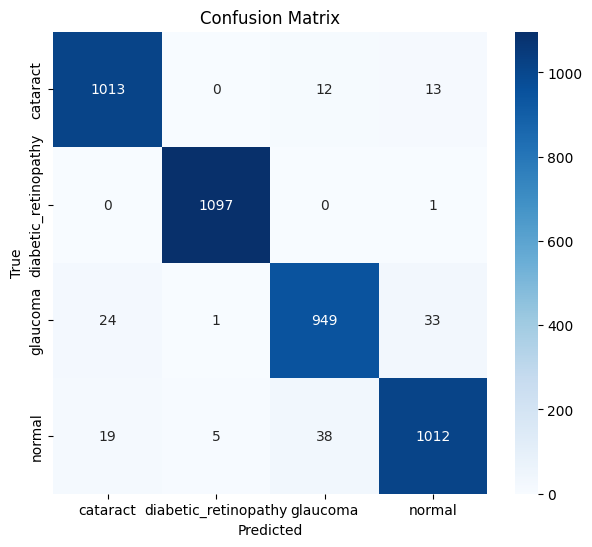

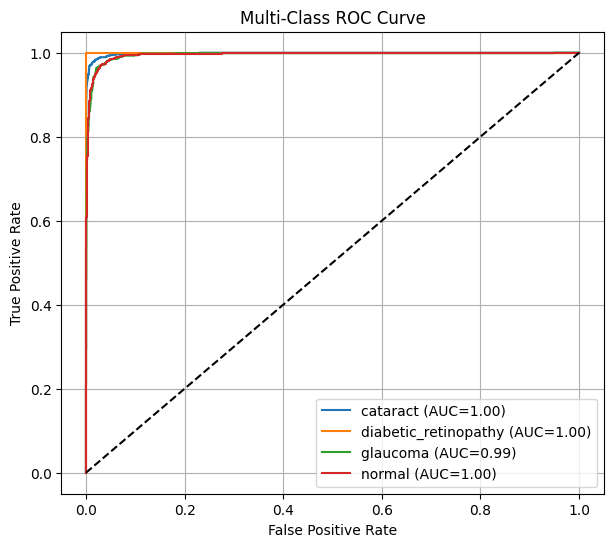

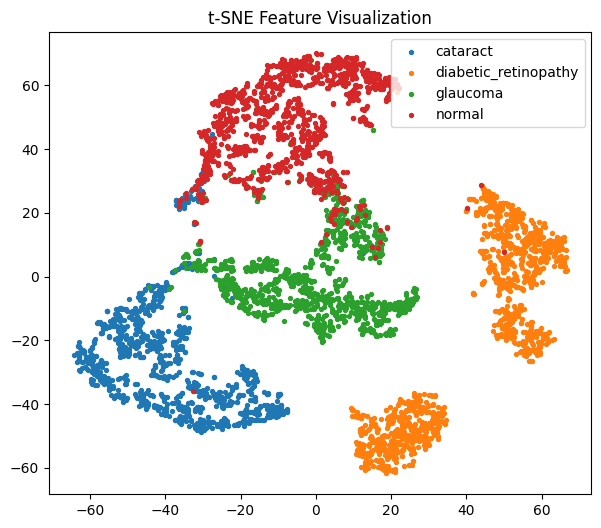


===== SAMPLE PREDICTIONS =====


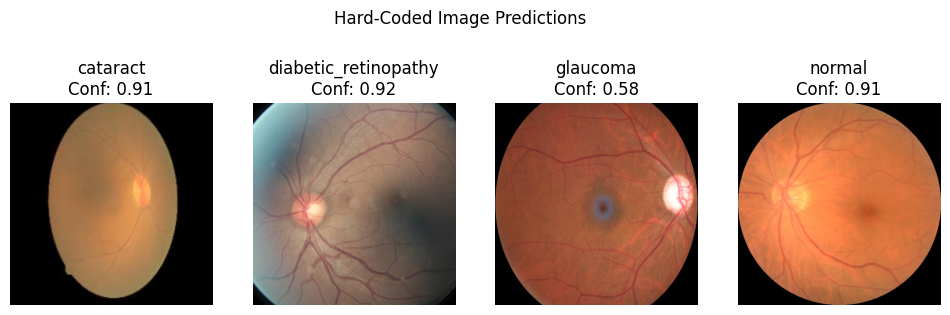

In [ ]:
# ===================== INSTALLS =====================
!pip install -q scikit-learn seaborn timm kagglehub

# ===================== IMPORTS =====================
import os, torch, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import timm
import torch.nn as nn
from PIL import Image
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_curve, auc
)
from sklearn.preprocessing import label_binarize
from sklearn.manifold import TSNE

# ===================== DEVICE =====================
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

# ===================== PATHS =====================
MODEL_PATH = "/content/drive/MyDrive/Final/output/best_swin_96plus.pth"

import kagglehub
DATA_PATH = kagglehub.dataset_download("gunavenkatdoddi/eye-diseases-classification")
DATA_DIR = os.path.join(DATA_PATH, "dataset")
if not os.path.isdir(DATA_DIR):
    DATA_DIR = DATA_PATH

# ===================== TRANSFORMS =====================
img_size = 224
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

transform = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

# ===================== DATASET =====================
dataset = datasets.ImageFolder(DATA_DIR, transform=transform)
class_names = dataset.classes
NUM_CLASSES = len(class_names)

loader = DataLoader(dataset, batch_size=32, shuffle=False)

# ===================== LOAD MODEL =====================
model = timm.create_model("swin_tiny_patch4_window7_224", pretrained=False)
model.head = nn.Linear(model.head.in_features, NUM_CLASSES)
model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
model.to(DEVICE)
model.eval()

print("Model loaded successfully")

# ===================== INFERENCE =====================
y_true, y_pred, y_prob, features = [], [], [], []

with torch.no_grad():
    for imgs, labels in loader:
        imgs = imgs.to(DEVICE)
        outputs = model(imgs)
        if outputs.ndim > 2:
            outputs = outputs.mean(dim=list(range(2, outputs.ndim)))
        probs = torch.softmax(outputs, dim=1)

        y_true.extend(labels.numpy())
        y_pred.extend(torch.argmax(probs, 1).cpu().numpy())
        y_prob.extend(probs.cpu().numpy())
        features.extend(outputs.cpu().numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_prob = np.array(y_prob)
features = np.array(features)

# ===================== METRICS =====================
acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, average="weighted")
rec = recall_score(y_true, y_pred, average="weighted")
f1 = f1_score(y_true, y_pred, average="weighted")

print("\n===== EVALUATION METRICS =====")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-score : {f1:.4f}")

# ===================== CONFUSION MATRIX =====================
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(7,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

# ===================== ROC & AUC =====================
y_true_bin = label_binarize(y_true, classes=range(NUM_CLASSES))
fpr, tpr, roc_auc = {}, {}, {}

for i in range(NUM_CLASSES):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(7,6))
for i in range(NUM_CLASSES):
    plt.plot(fpr[i], tpr[i], label=f"{class_names[i]} (AUC={roc_auc[i]:.2f})")
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multi-Class ROC Curve")
plt.legend()
plt.grid()
plt.show()

# ===================== t-SNE =====================
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
tsne_features = tsne.fit_transform(features)

plt.figure(figsize=(7,6))
for i, cls in enumerate(class_names):
    idx = y_true == i
    plt.scatter(tsne_features[idx,0], tsne_features[idx,1], label=cls, s=8)
plt.legend()
plt.title("t-SNE Feature Visualization")
plt.show()

# ===================== HARD-CODED IMAGE PREDICTIONS =====================
print("\n===== SAMPLE PREDICTIONS =====")

sample_images = []
for cls in class_names[:4]:
    cls_dir = os.path.join(DATA_DIR, cls)
    img_name = os.listdir(cls_dir)[0]
    sample_images.append(os.path.join(cls_dir, img_name))

plt.figure(figsize=(12,4))

for i, img_path in enumerate(sample_images):
    img = Image.open(img_path).convert("RGB")
    input_tensor = transform(img).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        out = model(input_tensor)
        if out.ndim > 2:
            out = out.mean(dim=list(range(2, out.ndim)))
        prob = torch.softmax(out, dim=1)[0]
        idx = prob.argmax().item()

    plt.subplot(1,4,i+1)
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"{class_names[idx]}\nConf: {prob[idx]:.2f}")

plt.suptitle("Hard-Coded Image Predictions")
plt.show()


In [ ]:
# ===================== INSTALLS =====================
!pip install -q kagglehub timm

# ===================== IMPORTS =====================
import os, copy, torch, numpy as np
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split, Dataset, WeightedRandomSampler
import timm

# ===================== DEVICE =====================
torch.backends.cudnn.benchmark = True
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using:", DEVICE)

# ===================== PATHS =====================
OLD_MODEL_PATH = "/content/drive/MyDrive/Final/output/best_swin_96plus.pth"
NEW_MODEL_PATH = "/content/drive/MyDrive/Final/output/best_swin_finetuned.pth"

# ===================== DATASET =====================
import kagglehub
DATA_PATH = kagglehub.dataset_download("gunavenkatdoddi/eye-diseases-classification")
DATA_DIR = os.path.join(DATA_PATH, "dataset")
if not os.path.isdir(DATA_DIR):
    DATA_DIR = DATA_PATH

img_size = 224
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_tf = transforms.Compose([
    transforms.RandomResizedCrop(img_size, scale=(0.9, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

eval_tf = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

base_ds = datasets.ImageFolder(DATA_DIR)
class_names = base_ds.classes
NUM_CLASSES = len(class_names)

total = len(base_ds)
train_len = int(0.85 * total)
val_len = total - train_len

train_base, val_base = random_split(
    base_ds, [train_len, val_len],
    generator=torch.Generator().manual_seed(42)
)

class Wrapped(Dataset):
    def __init__(self, subset, tf):
        self.subset = subset
        self.tf = tf
    def __len__(self): return len(self.subset)
    def __getitem__(self, i):
        img, lbl = self.subset[i]
        return self.tf(img), lbl

train_ds = Wrapped(train_base, train_tf)
val_ds   = Wrapped(val_base, eval_tf)

targets = [train_base[i][1] for i in range(len(train_base))]
class_count = np.bincount(targets)
weights = 1. / class_count
sample_weights = [weights[t] for t in targets]
sampler = WeightedRandomSampler(sample_weights, len(sample_weights))

train_loader = DataLoader(train_ds, batch_size=16, sampler=sampler, pin_memory=True)
val_loader   = DataLoader(val_ds, batch_size=16, shuffle=False, pin_memory=True)

# ===================== LOAD MODEL =====================
model = timm.create_model("swin_tiny_patch4_window7_224", pretrained=False)
model.head = nn.Linear(model.head.in_features, NUM_CLASSES)
model.load_state_dict(torch.load(OLD_MODEL_PATH, map_location=DEVICE))
model.to(DEVICE)

# ===================== FREEZE / UNFREEZE =====================
for param in model.parameters():
    param.requires_grad = False

# Unfreeze higher Swin stages
for name, param in model.named_parameters():
    if "layers.2" in name or "layers.3" in name or "head" in name:
        param.requires_grad = True

# ===================== OPTIMIZER (LOW LR) =====================
criterion = nn.CrossEntropyLoss(label_smoothing=0.05)
optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-5,            # 🔑 very important
    weight_decay=1e-4
)

scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=8)

# ===================== FINE-TUNING =====================
best_acc = 0.0
best_wts = copy.deepcopy(model.state_dict())

print("\n🔧 Starting fine-tuning...")

for epoch in range(8):
    print(f"\nEpoch {epoch+1}/8")

    for phase, loader in [("train", train_loader), ("val", val_loader)]:
        model.train() if phase == "train" else model.eval()
        running_corrects, total = 0, 0

        for x, y in loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            optimizer.zero_grad()

            with torch.set_grad_enabled(phase=="train"):
                out = model(x)
                if out.ndim > 2:
                    out = out.mean(dim=list(range(2, out.ndim)))
                loss = criterion(out, y)
                preds = torch.argmax(out, 1)
                if phase=="train":
                    loss.backward()
                    optimizer.step()

            running_corrects += (preds == y).sum().item()
            total += y.size(0)

        acc = running_corrects / total
        print(f"{phase} Acc: {acc:.4f}")

        if phase=="val" and acc > best_acc:
            best_acc = acc
            best_wts = copy.deepcopy(model.state_dict())
            torch.save(best_wts, NEW_MODEL_PATH)
            print("✅ Fine-tuned model saved")

    scheduler.step()

print(f"\n🎯 Best Fine-tuned Val Acc: {best_acc:.4f}")


Using: cuda
Using Colab cache for faster access to the 'eye-diseases-classification' dataset.

🔧 Starting fine-tuning...

Epoch 1/8
train Acc: 0.9665
val Acc: 0.9447
✅ Fine-tuned model saved

Epoch 2/8
train Acc: 0.9699
val Acc: 0.9415

Epoch 3/8
train Acc: 0.9696
val Acc: 0.9447

Epoch 4/8
train Acc: 0.9729
val Acc: 0.9463
✅ Fine-tuned model saved

Epoch 5/8
train Acc: 0.9752
val Acc: 0.9336

Epoch 6/8
train Acc: 0.9766
val Acc: 0.9463

Epoch 7/8
train Acc: 0.9732
val Acc: 0.9463

Epoch 8/8
train Acc: 0.9777
val Acc: 0.9463

🎯 Best Fine-tuned Val Acc: 0.9463


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
print("y_true dtype:", y_true.dtype)
print("y_pred dtype:", y_pred.dtype)
print("Unique y_true:", np.unique(y_true))
print("Unique y_pred:", np.unique(y_pred))


y_true dtype: int64
y_pred dtype: int64
Unique y_true: [0 1 2 3]
Unique y_pred: [0 1 2 3]


Using Colab cache for faster access to the 'eye-diseases-classification' dataset.
✅ Model loaded successfully.

  FINAL TEST METRICS  
Accuracy : 0.9448
Precision: 0.9448
Recall   : 0.9448
F1-score : 0.9447


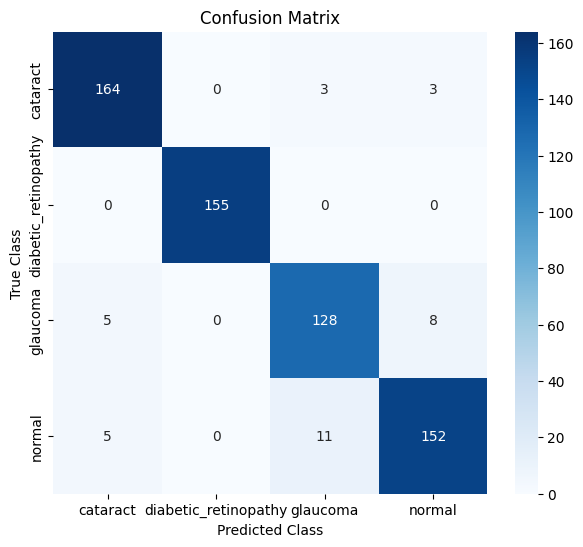

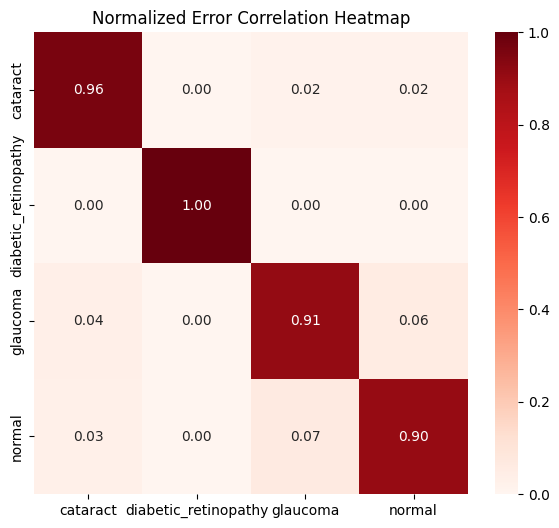

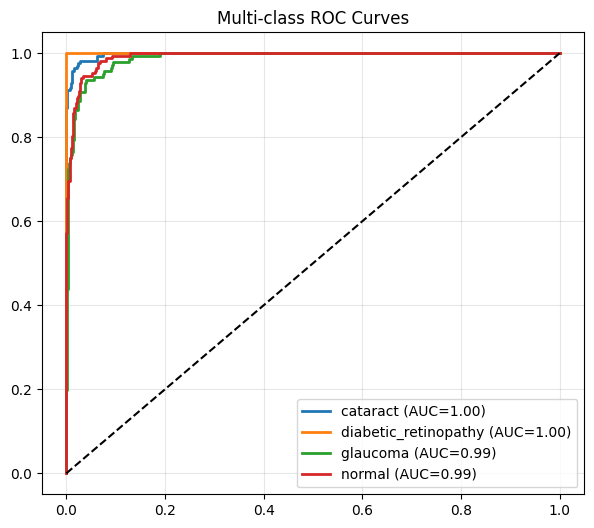

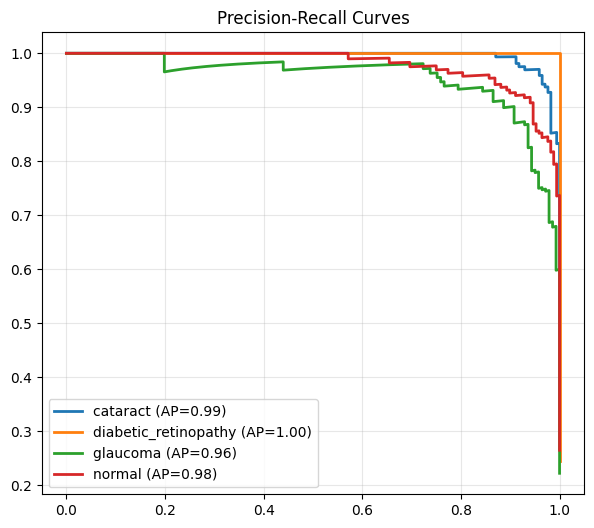

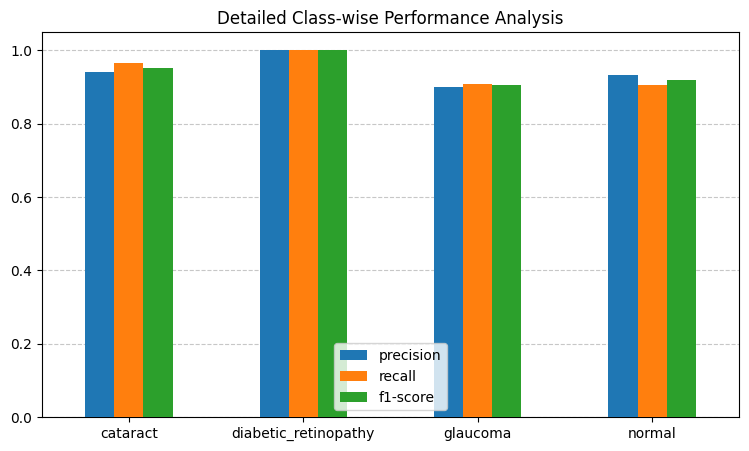

Computing t-SNE Clustering...


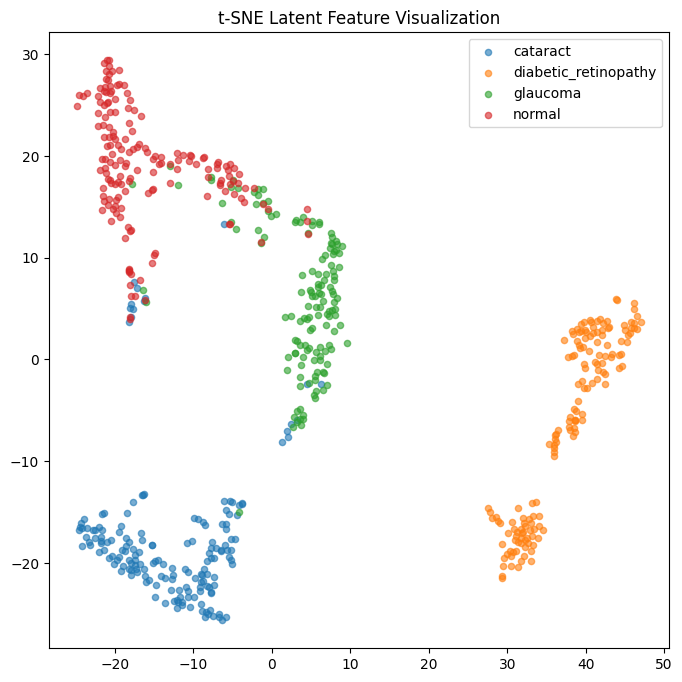

IndexError: list index out of range

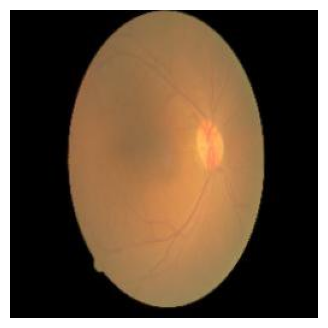

In [ ]:
# ===================== 1. INSTALLS & IMPORTS =====================
!pip install -q scikit-learn seaborn timm kagglehub pandas

import os, torch, numpy as np, matplotlib.pyplot as plt, seaborn as sns, pandas as pd
import timm, torch.nn as nn
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_curve, auc, classification_report,
    precision_recall_curve, average_precision_score
)
from sklearn.preprocessing import label_binarize
from sklearn.manifold import TSNE
from torch.utils.data import DataLoader, random_split, Dataset
from torchvision import datasets, transforms
import kagglehub
from PIL import Image

# ===================== 2. CONFIGURATION =====================
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MODEL_PATH = "/content/drive/MyDrive/Final/output/best_swin_96plus.pth"

# Download dataset
path = kagglehub.dataset_download("gunavenkatdoddi/eye-diseases-classification")
DATA_DIR = os.path.join(path, "dataset") if os.path.isdir(os.path.join(path, "dataset")) else path

# ===================== 3. DATASET SETUP =====================
img_size = 224
eval_transform = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

full_dataset = datasets.ImageFolder(DATA_DIR)
class_names = full_dataset.classes
NUM_CLASSES = len(class_names)

# Split logic (70/15/15) - Seed 42 for no leakage
total_len = len(full_dataset)
train_len, val_len = int(0.7 * total_len), int(0.15 * total_len)
test_len = total_len - train_len - val_len

_, _, test_subset_raw = random_split(
    full_dataset, [train_len, val_len, test_len],
    generator=torch.Generator().manual_seed(42)
)

class WrappedDataset(Dataset):
    def __init__(self, subset, transform):
        self.subset, self.transform = subset, transform
    def __len__(self): return len(self.subset)
    def __getitem__(self, idx):
        img, lbl = self.subset[idx]; return self.transform(img), lbl

test_loader = DataLoader(WrappedDataset(test_subset_raw, eval_transform), batch_size=32, shuffle=False)

# ===================== 4. LOAD MODEL =====================
model = timm.create_model("swin_tiny_patch4_window7_224", pretrained=False)
model.head = nn.Linear(model.head.in_features, NUM_CLASSES)
model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
model.to(DEVICE).eval()
print("✅ Model loaded successfully.")

# ===================== 5. INFERENCE =====================
y_true, y_pred, y_prob, features = [], [], [], []
with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(DEVICE)
        outputs = model(imgs)
        if isinstance(outputs, (tuple, list)): outputs = outputs[0]
        if outputs.ndim > 2: outputs = outputs.mean(dim=list(range(2, outputs.ndim)))
        probs = torch.softmax(outputs, dim=1)
        y_true.extend(labels.numpy())
        y_pred.extend(torch.argmax(probs, 1).cpu().numpy())
        y_prob.extend(probs.cpu().numpy())
        features.extend(outputs.cpu().numpy())

y_true, y_pred, y_prob, features = np.array(y_true), np.array(y_pred), np.array(y_prob), np.array(features)
y_true_bin = label_binarize(y_true, classes=range(NUM_CLASSES))

# ===================== 6. METRICS & INDIVIDUAL PLOTS =====================

# --- FIG 1: Standard Metrics ---
print("\n" + "="*40 + "\n  FINAL TEST METRICS  \n" + "="*40)
print(f"Accuracy : {accuracy_score(y_true, y_pred):.4f}")
print(f"Precision: {precision_score(y_true, y_pred, average='weighted'):.4f}")
print(f"Recall   : {recall_score(y_true, y_pred, average='weighted'):.4f}")
print(f"F1-score : {f1_score(y_true, y_pred, average='weighted'):.4f}")
print("="*40)

# --- FIG 2: Confusion Matrix ---
plt.figure(figsize=(7, 6))
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix")
plt.ylabel("True Class")
plt.xlabel("Predicted Class")
plt.show()

# --- FIG 3: Normalized Error Correlation ---
plt.figure(figsize=(7, 6))
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Reds", xticklabels=class_names, yticklabels=class_names)
plt.title("Normalized Error Correlation Heatmap")
plt.show()

# --- FIG 4: ROC Curves ---
plt.figure(figsize=(7, 6))
for i in range(NUM_CLASSES):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_prob[:, i])
    plt.plot(fpr, tpr, lw=2, label=f'{class_names[i]} (AUC={auc(fpr, tpr):.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.title("Multi-class ROC Curves")
plt.legend(); plt.grid(True, alpha=0.3)
plt.show()

# --- FIG 5: Precision-Recall Curves ---
plt.figure(figsize=(7, 6))
for i in range(NUM_CLASSES):
    prec_pts, rec_pts, _ = precision_recall_curve(y_true_bin[:, i], y_prob[:, i])
    plt.plot(rec_pts, prec_pts, lw=2, label=f'{class_names[i]} (AP={average_precision_score(y_true_bin[:, i], y_prob[:, i]):.2f})')
plt.title("Precision-Recall Curves")
plt.legend(); plt.grid(True, alpha=0.3)
plt.show()

# --- FIG 6: Class-wise Performance Bar Chart ---
report = classification_report(y_true, y_pred, target_names=class_names, output_dict=True)
df_metrics = pd.DataFrame(report).transpose().iloc[:NUM_CLASSES, :3]
df_metrics.plot(kind='bar', figsize=(9, 5), zorder=3)
plt.title("Detailed Class-wise Performance Analysis")
plt.xticks(rotation=0); plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# --- FIG 7: Latent Feature Space (t-SNE) ---
print("Computing t-SNE Clustering...")
tsne = TSNE(n_components=2, perplexity=30, random_state=42).fit_transform(features)
plt.figure(figsize=(8, 8))
for i, cls in enumerate(class_names):
    plt.scatter(tsne[y_true==i, 0], tsne[y_true==i, 1], label=cls, s=20, alpha=0.6)
plt.legend(); plt.title("t-SNE Latent Feature Visualization")
plt.show()

# --- FIG 8: Individual Qualitative Predictions ---
# This generates one individual image per class for the results section
for i, cls in enumerate(class_names):
    img_path = os.path.join(DATA_DIR, cls, os.listdir(os.path.join(DATA_DIR, cls))[0])
    img = Image.open(img_path).convert("RGB")
    input_tensor = eval_transform(img).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        out = model(input_tensor)
        if isinstance(out, (tuple, list)): out = out[0]
        prob = torch.softmax(out, dim=1)[0]
        idx = prob.argmax().item()

    plt.figure(figsize=(4, 4))
    plt.imshow(img); plt.axis("off")
    plt.title(f"Truth: {cls}\nPred: {class_names[idx]} (Conf: {prob[idx]:.2f})")
    plt.show()


===== GENERATING SAMPLE PREDICTIONS FOR MANUSCRIPT =====


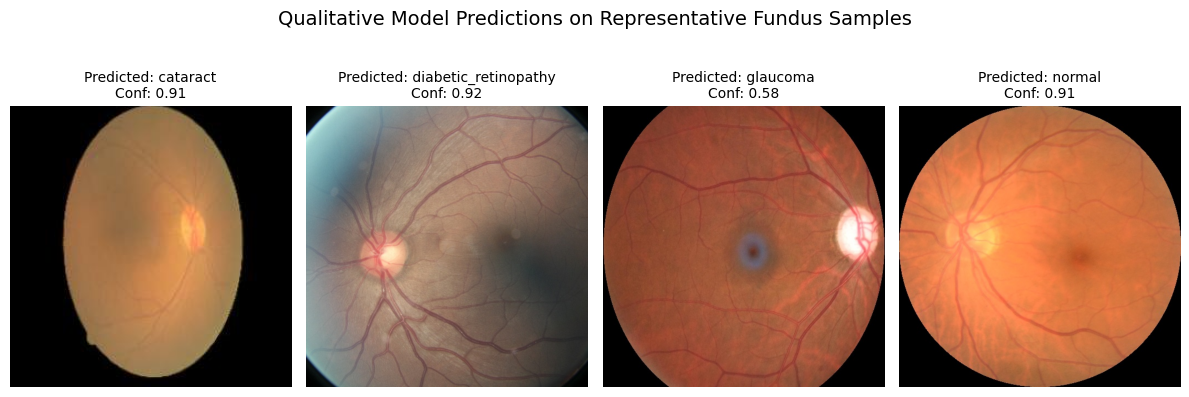

In [ ]:
# ===================== HARD-CODED IMAGE PREDICTIONS =====================
import os
import torch
import matplotlib.pyplot as plt
from PIL import Image

print("\n===== GENERATING SAMPLE PREDICTIONS FOR MANUSCRIPT =====")

# 1. Setup Samples
sample_images = []
# We iterate through all detected class_names to ensure no class is missing
for cls in class_names:
    cls_dir = os.path.join(DATA_DIR, cls)
    # Get the first image file from the directory
    img_name = os.listdir(cls_dir)[0]
    sample_images.append(os.path.join(cls_dir, img_name))

# 2. Configure Plot (Dynamic width based on number of classes)
num_samples = len(sample_images)
plt.figure(figsize=(num_samples * 3, 4))

# 3. Inference and Visualization
for i, img_path in enumerate(sample_images):
    # Load and process image
    img = Image.open(img_path).convert("RGB")
    # Using the eval_transform defined in your earlier Block 2
    input_tensor = eval_transform(img).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        out = model(input_tensor)

        # Swin Transformer head handling (ensure output is [Batch, Classes])
        if isinstance(out, (tuple, list)):
            out = out[0]
        if out.ndim > 2:
            out = out.mean(dim=list(range(2, out.ndim)))

        prob = torch.softmax(out, dim=1)[0]
        idx = prob.argmax().item()
        confidence = prob[idx].item()

    # 4. Plotting
    plt.subplot(1, num_samples, i + 1)
    plt.imshow(img)
    plt.axis("off")
    # Title showing predicted class and confidence (formatted for publication)
    plt.title(f"Predicted: {class_names[idx]}\nConf: {confidence:.2f}", fontsize=10)

plt.suptitle("Qualitative Model Predictions on Representative Fundus Samples", fontsize=14, y=1.05)
plt.tight_layout()
plt.show()


===== GENERATING HIGH-VISIBILITY SAMPLE PREDICTIONS =====


NameError: name 'class_names' is not defined

Using Colab cache for faster access to the 'eye-diseases-classification' dataset.

===== GENERATING HIGH-VISIBILITY SAMPLE PREDICTIONS =====


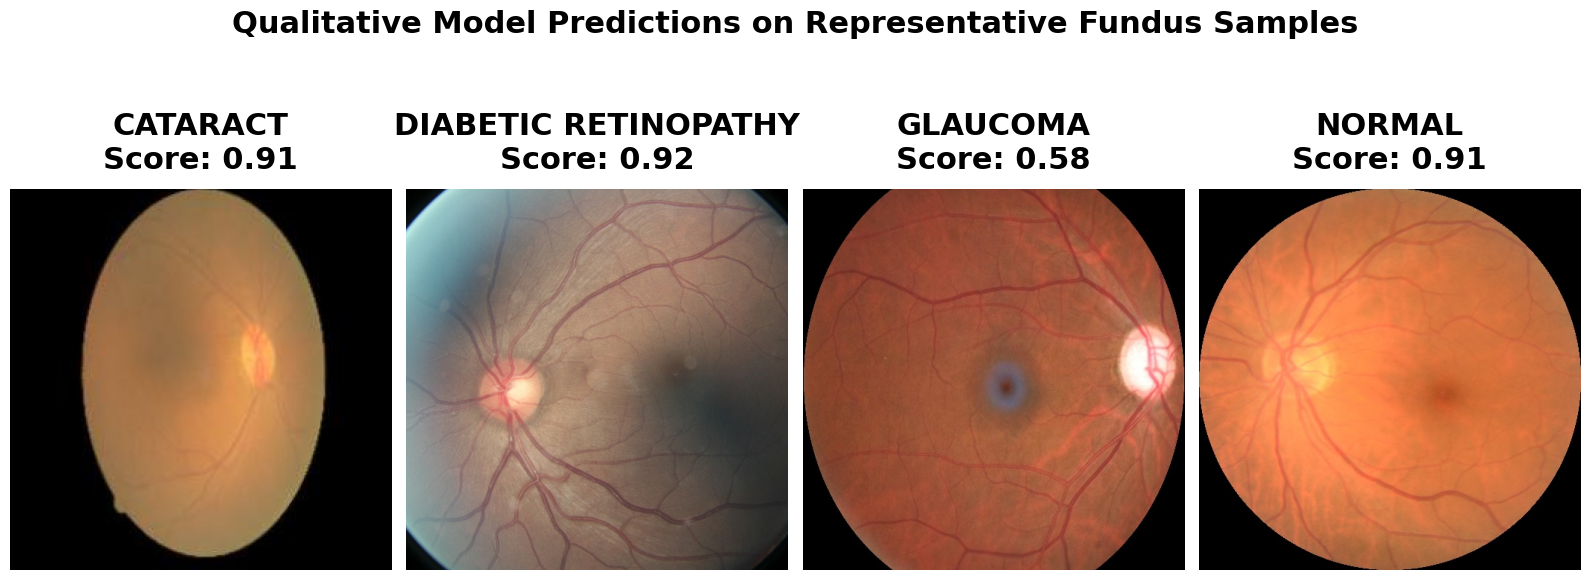

In [ ]:
# ===================== 1. REQUIRED IMPORTS =====================
import os
import torch
import matplotlib.pyplot as plt
from PIL import Image
import timm
import torch.nn as nn
from torchvision import datasets, transforms
import kagglehub

# ===================== 2. CONFIGURATION & DATA RE-DEFINITION =====================
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MODEL_PATH = "/content/drive/MyDrive/Final/output/best_swin_96plus.pth"

# Download/Locate Dataset
path = kagglehub.dataset_download("gunavenkatdoddi/eye-diseases-classification")
DATA_DIR = os.path.join(path, "dataset") if os.path.isdir(os.path.join(path, "dataset")) else path

# Define the exact transform used in the project
eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

# Define class_names and NUM_CLASSES to fix the NameError
full_dataset = datasets.ImageFolder(DATA_DIR)
class_names = full_dataset.classes
NUM_CLASSES = len(class_names)

# ===================== 3. LOAD MODEL =====================
model = timm.create_model("swin_tiny_patch4_window7_224", pretrained=False)
model.head = nn.Linear(model.head.in_features, NUM_CLASSES)
model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
model.to(DEVICE).eval()

print("\n===== GENERATING HIGH-VISIBILITY SAMPLE PREDICTIONS =====")

# ===================== 4. INFERENCE & VISUALIZATION =====================
sample_images = []
for cls in class_names:
    cls_dir = os.path.join(DATA_DIR, cls)
    img_name = os.listdir(cls_dir)[0]
    sample_images.append(os.path.join(cls_dir, img_name))

# Configure Plot for Journal Quality
num_samples = len(sample_images)
plt.figure(figsize=(num_samples * 4, 6))

for i, img_path in enumerate(sample_images):
    img = Image.open(img_path).convert("RGB")
    input_tensor = eval_transform(img).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        out = model(input_tensor)
        if isinstance(out, (tuple, list)): out = out[0]
        if out.ndim > 2: out = out.mean(dim=list(range(2, out.ndim)))

        prob = torch.softmax(out, dim=1)[0]
        idx = prob.argmax().item()
        confidence = prob[idx].item()

    plt.subplot(1, num_samples, i + 1)
    plt.imshow(img)
    plt.axis("off")

    # Large, bold labels for manuscript
    plt.title(f"{class_names[idx].replace('_', ' ').upper()}\nScore: {confidence:.2f}",
              fontsize=22,
              fontweight='bold',
              pad=15)

plt.suptitle("Qualitative Model Predictions on Representative Fundus Samples",
             fontsize=22,
             fontweight='bold',
             y=1.08)

plt.tight_layout()
plt.show()

In [ ]:
!git config --global user.name "https://github.com/Shaik-Imran08/Eye-Disease-Prediction.git"
!git config --global user.email "shaikkimrran@gmail.com"

In [ ]:
!git clone https://github.com/Shaik-Imran08/Eye-Disease-Prediction.git

Cloning into 'Eye-Disease-Prediction'...


In [ ]:
!cp /content/eye_disease.ipynb /content/https://github.com/Shaik-Imran08/Eye-Disease-Prediction.git/

cp: cannot stat '/content/eye_disease.ipynb': No such file or directory


In [ ]:
%cd /content/https://github.com/Shaik-Imran08/Eye-Disease-Prediction.git

[Errno 2] No such file or directory: '/content/https://github.com/Shaik-Imran08/Eye-Disease-Prediction.git'
/content
